In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# DATA EXPLORATION

In [2]:
df = pd.read_csv('/content/train-data.csv')
df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


In [4]:
pd.options.display.float_format = '{:,.1f}'.format
df.describe()

,Unnamed: 0,Year,Kilometers_Driven,Seats,Price
count,"6,019.0","6,019.0","6,019.0","5,977.0","6,019.0"
mean,"3,009.0","2,013.4","58,738.4",5.3,9.5
std,"1,737.7",3.3,"91,268.8",0.8,11.2
min,0.0,"1,998.0",171.0,0.0,0.4
25%,"1,504.5","2,011.0","34,000.0",5.0,3.5
50%,"3,009.0","2,014.0","53,000.0",5.0,5.6
75%,"4,513.5","2,016.0","73,000.0",5.0,9.9
max,"6,018.0","2,019.0","6,500,000.0",10.0,160.0


In [5]:
df.describe(include='O')

,Name,Location,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,New_Price
count,6019,6019,6019,6019,6019,6017,5983,5983,824
unique,1876,11,5,2,4,442,146,372,540
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First,18.9 kmpl,1197 CC,74 bhp,95.13 Lakh
freq,49,790,3205,4299,4929,172,606,235,6


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
pd.options.display.float_format = '{:,.3f}'.format
df.isnull().mean() *100

,0
Unnamed: 0,0.000
Name,0.000
Location,0.000
Year,0.000
Kilometers_Driven,0.000
Fuel_Type,0.000
Transmission,0.000
Owner_Type,0.000
Mileage,0.033
Engine,0.598


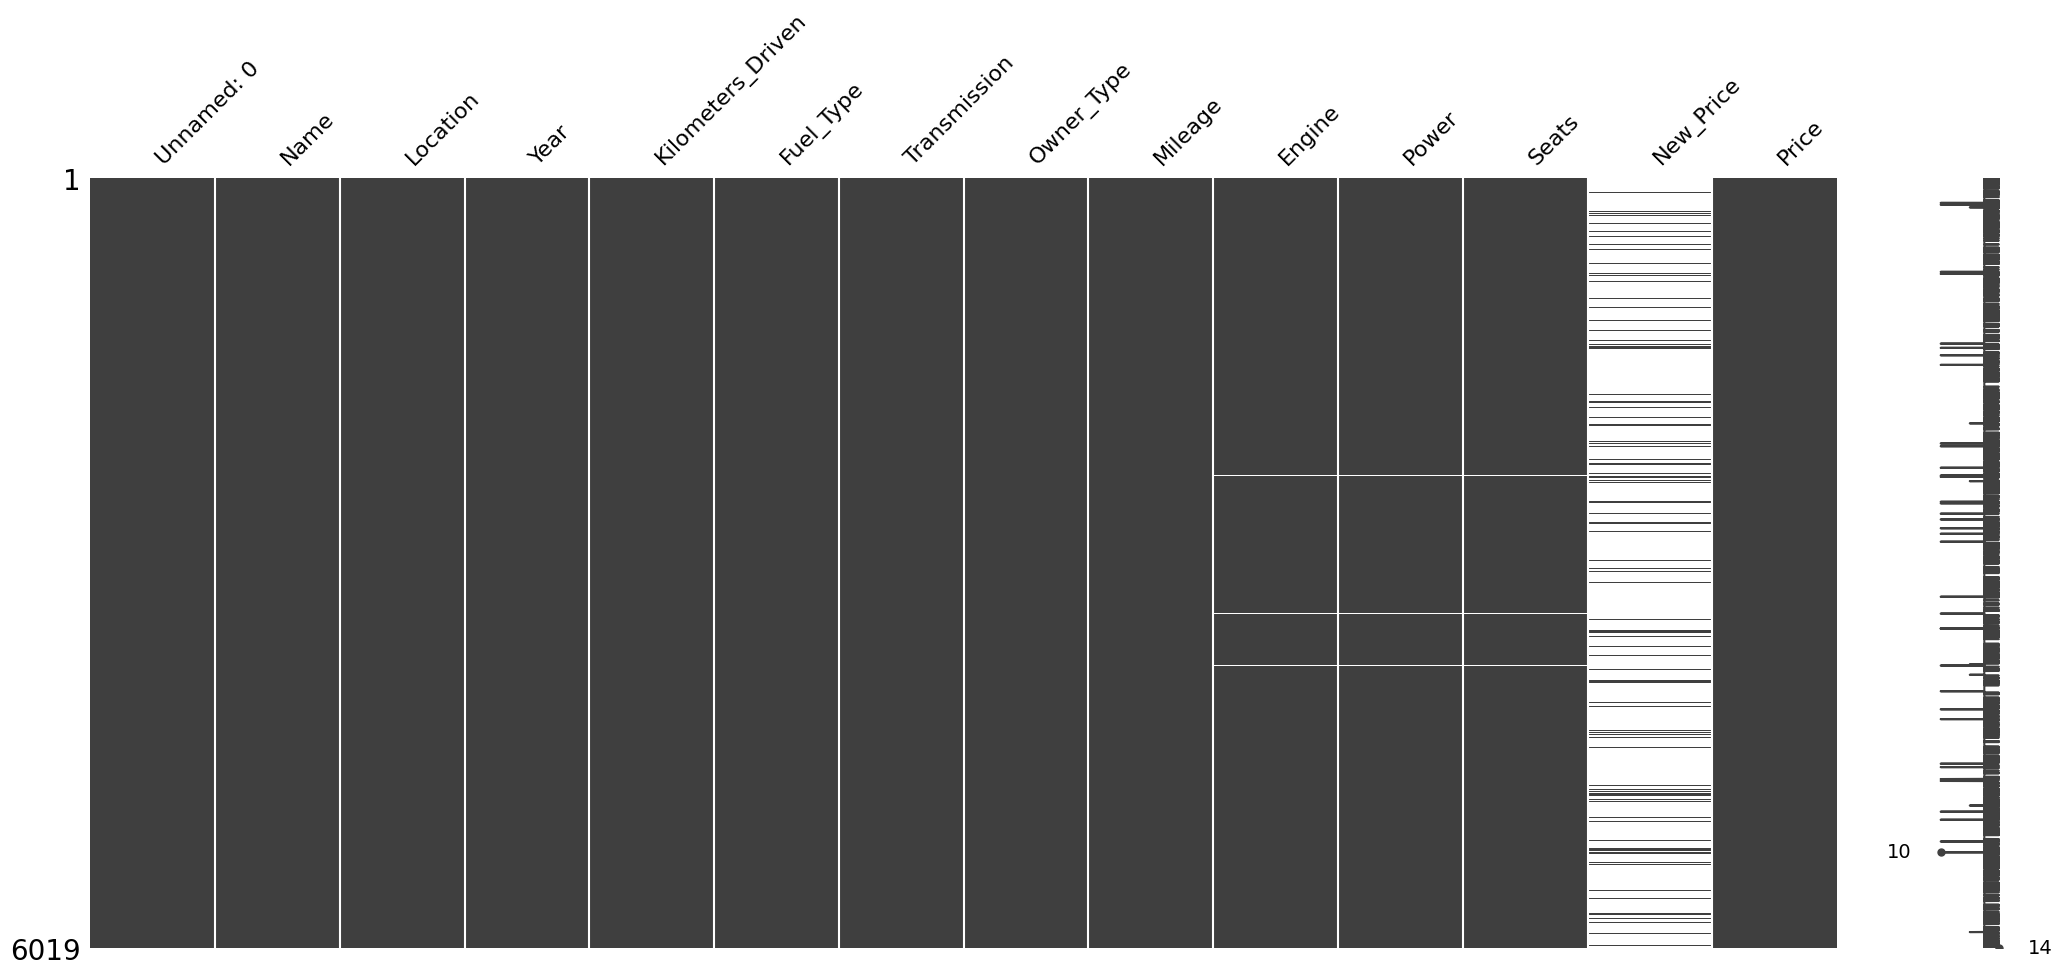

In [8]:
import missingno as msno

msno.matrix(df)
plt.show()

<Axes: >

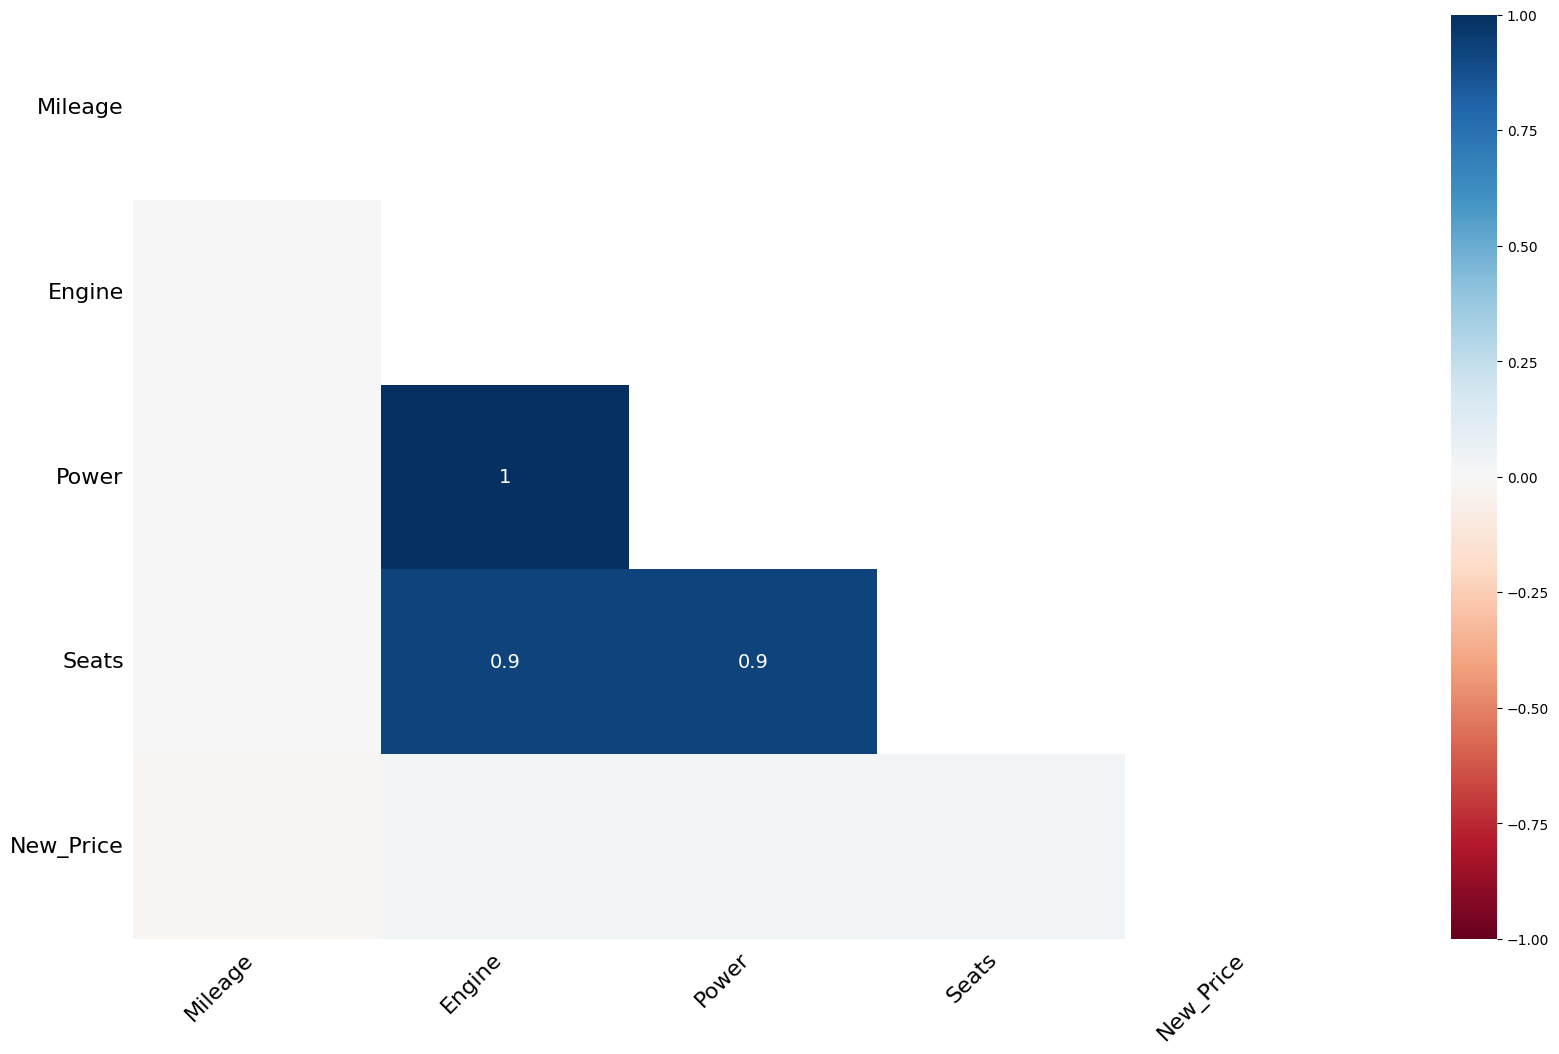

In [9]:
msno.heatmap(df)

In [10]:
# Drop Unnamed: 0 & New Price
df.drop(columns=['Unnamed: 0', 'New_Price'], inplace=True)

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    fig = px.histogram(df, x=col, marginal='box', title=f'Distribution of {col}', nbins=30)
    fig.show()


After our initial exploration, here are the key observations and our planned approach for preprocessing each feature:

---

#### **Data Cleaning & Feature Engineering Plan**

| Feature            | Type              | Observations                                                      | Action Plan                                                                 |
|--------------------|-------------------|-------------------------------------------------------------------|------------------------------------------------------------------------------|
| **Unnamed: 0**     | Integer           | Appears to be an index column                                     | **Drop** — redundant as pandas has its own index                            |
| **Name**           | Object    | Contains full car name with brand and model information           | **Feature engineering** — extract **Brand** and **Model** as separate features |
| **Location**       | Object    | Categorical variable representing city/location                   | **Encoding** — use appropriate categorical encoding technique                |
| **Year**           | Integer           | Manufacturing year of the vehicle                                 | **Transform** — create `Age` feature: `Current_Year - Year` or `(Max_Year + 1 - Year)` |
| **Kilometers_Driven** | Integer        | Total distance driven by the vehicle                              | **Handle outliers** — identify and treat extreme values                      |
| **Fuel_Type**      | Object    | Type of fuel the vehicle uses                                     | **Encoding** — convert to numerical representation; **special attention** to “Electric” |
| **Transmission**   | Object    | Type of transmission (Manual/Automatic)                           | **Encoding** — convert to binary/ordinal representation                      |
| **Owner_Type**     | Object    | Number of previous owners                                         | **Encoding** — apply ordinal encoding where appropriate                      |
| **Mileage**        | Object    | Contains numbers with units (e.g., km/kg, kmpl)                   | **Extract numeric values** — remove units and convert to float               |
| **Engine**         | Object    | Contains numbers with units (CC)                                  | **Extract numeric values** — remove `CC` and convert to float                |
| **Power**          | Object    | Contains numbers with units (bhp)                                 | **Extract numeric values** — remove `bhp` and convert to float               |
| **Seats**          | Float             | Number of seats; zeros may indicate missing data                  | **Handle zeros** — treat zeros as missing and **impute** appropriately       |
| **New_Price**      | Object    | Price of new version of the vehicle                               | **Drop** — too many missing values (insufficient for reliable imputation)    |

---

#### **Key Challenges Identified**

- **Mixed data types:** Several columns (`Mileage`, `Engine`, `Power`) contain numbers with units that need extraction.  
- **Categorical variables:** Multiple features need encoding (`Location`, `Fuel_Type`, `Transmission`, `Owner_Type`).  
- **Temporal data:** `Year` needs transformation into a more meaningful feature (`Age`).  
- **Potential outliers:** `Kilometers_Driven` likely contains extreme values that need treatment.  
- **Missing data:** `New_Price` has excessive missing values; `Seats` may have zeros representing missing data.  
- **Special categories:** `'Electric'` in `Fuel_Type` may require special handling due to different characteristics.


# DATA CLEANING

In [12]:
df.Name.sample(10)

,Name
1435,Mahindra XUV500 W8 2WD
1122,Honda City i VTEC CVT VX
382,Mercedes-Benz E-Class 2009-2013 E250 CDI Avant...
2333,Nissan Terrano XL D Option
276,Mahindra Scorpio VLX 2.2 mHawk Airbag BSIV
1044,Audi A4 35 TDI Technology
3709,Honda City 1.5 S MT
3068,Honda City 1.5 EXI AT
4504,Renault Duster 110PS Diesel RxL
2597,Hyundai Santro Xing XP


In [13]:
df.Name.str.contains('Land Rover').sum()

np.int64(60)

In [14]:
df.Name[df.Name.str.contains('Land Rover')].sample(5)

,Name
5477,Land Rover Range Rover HSE Dynamic
3242,Land Rover Range Rover Vogue SE 4.4 SDV8
1038,Land Rover Range Rover TDV8 (Diesel)
13,Land Rover Range Rover 2.2L Pure
941,Land Rover Range Rover Evoque 2.0 TD4 HSE Dynamic


In [15]:
sample_car = df.loc[10, 'Name']
sample_car.split(' ')[0]  # Brand

'Maruti'

In [16]:
def get_brand(name):
    if name.startswith('Land Rover'):
        return 'Land Rover'
    return name.split(' ')[0]

sample_car = df.loc[1505, 'Name']
get_brand(sample_car)

'Land Rover'

In [17]:
df['Brand'] = df.Name.apply(get_brand)

In [18]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.000,1.750,Maruti
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.000,12.500,Hyundai
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.000,4.500,Honda
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.000,6.000,Maruti
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.000,17.740,Audi


In [19]:
df[df.Name.str.contains('Land Rover')].sample(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand
5038,Land Rover Discovery Sport TD4 HSE 7S,Coimbatore,2019,24013,Diesel,Automatic,First,12.81 kmpl,1999 CC,148.31 bhp,7.000,56.140,Land Rover
4755,Land Rover Range Rover Evoque 2.0 TD4 HSE Dynamic,Hyderabad,2016,52000,Diesel,Automatic,First,15.68 kmpl,1999 CC,177 bhp,5.000,42.000,Land Rover
5067,Land Rover Discovery Sport SD4 HSE Luxury 7S,Coimbatore,2019,17201,Diesel,Automatic,First,12.51 kmpl,2179 CC,187.7 bhp,7.000,58.910,Land Rover
4152,Land Rover Range Rover 3.0 D,Mumbai,2003,75000,Diesel,Automatic,Second,0.0 kmpl,NaN,NaN,NaN,16.110,Land Rover
4814,Land Rover Freelander 2 SE,Delhi,2013,68000,Diesel,Automatic,Second,12.39 kmpl,2179 CC,147.51 bhp,5.000,15.750,Land Rover


In [20]:
import numpy as np
for i in np.random.randint(0, len(df), 5):
    sample_car = df.loc[i, 'Name']
    print(sample_car.split(' ')[1])   # MODEL

E-Class
Civic
A4
Micra
City


In [21]:
sample_car = df[df.Name.str.contains('Land Rover')].reset_index().loc[50, 'Name']
print(sample_car)

Land Rover Discovery Sport TD4 HSE 7S


In [22]:
def get_model(name):
    if name.startswith('Land Rover Range Rover'):
        return 'Range Rover'
    elif name.startswith('Land Rover'):
        return name.split(' ')[2]
    else:
        return name.split(' ')[1]

df['Model'] = df.Name.apply(get_model)

In [23]:
df[df.Name.str.contains('Land Rover')].sample(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
4630,Land Rover Freelander 2 HSE,Mumbai,2011,82000,Diesel,Automatic,Second,12.35 kmpl,2179 CC,187.74 bhp,5.000,13.900,Land Rover,Freelander
3242,Land Rover Range Rover Vogue SE 4.4 SDV8,Bangalore,2012,63000,Diesel,Automatic,Second,11.49 kmpl,4367 CC,335.3 bhp,5.000,65.000,Land Rover,Range Rover
4247,Land Rover Freelander 2 SE,Ahmedabad,2012,75000,Diesel,Automatic,Second,12.39 kmpl,2179 CC,147.51 bhp,5.000,17.500,Land Rover,Freelander
2263,Land Rover Range Rover 2.2L Prestige,Coimbatore,2014,64557,Diesel,Automatic,Second,12.7 kmpl,2179 CC,187.7 bhp,5.000,29.930,Land Rover,Range Rover
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0 kmpl,2179 CC,115 bhp,5.000,17.500,Land Rover,Freelander


In [24]:
df.describe(include='O')

,Name,Location,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Brand,Model
count,6019,6019,6019,6019,6019,6017,5983,5983,6019,6019
unique,1876,11,5,2,4,442,146,372,31,214
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First,18.9 kmpl,1197 CC,74 bhp,Maruti,Swift
freq,49,790,3205,4299,4929,172,606,235,1211,353


In [25]:
df.drop(columns=['Name'], inplace=True)

In [26]:
px.histogram(df, x='Kilometers_Driven', marginal='box', title='Km Distribution')

In [27]:
df[df.Kilometers_Driven == df.Kilometers_Driven.max()]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
2328,Chennai,2017,6500000,Diesel,Automatic,First,15.97 kmpl,2993 CC,258 bhp,5.000,65.000,BMW,X5


In [28]:
km_outlier = df[df.Kilometers_Driven == df.Kilometers_Driven.max()].index
df.drop(index=km_outlier, inplace=True)

In [29]:
px.histogram(df, x='Kilometers_Driven', marginal='box', title='Km Distribution')

In [30]:
df.Fuel_Type.unique()

array(['CNG', 'Diesel', 'Petrol', 'LPG', 'Electric'], dtype=object)

In [31]:
df[df.Fuel_Type == 'Electric']

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
4446,Chennai,2016,50000,Electric,Automatic,First,NaN,72 CC,41 bhp,5.000,13.000,Mahindra,E
4904,Mumbai,2011,44000,Electric,Automatic,First,NaN,1798 CC,73 bhp,5.000,12.750,Toyota,Prius


In [32]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,36
Power,36
Seats,42


<Axes: >

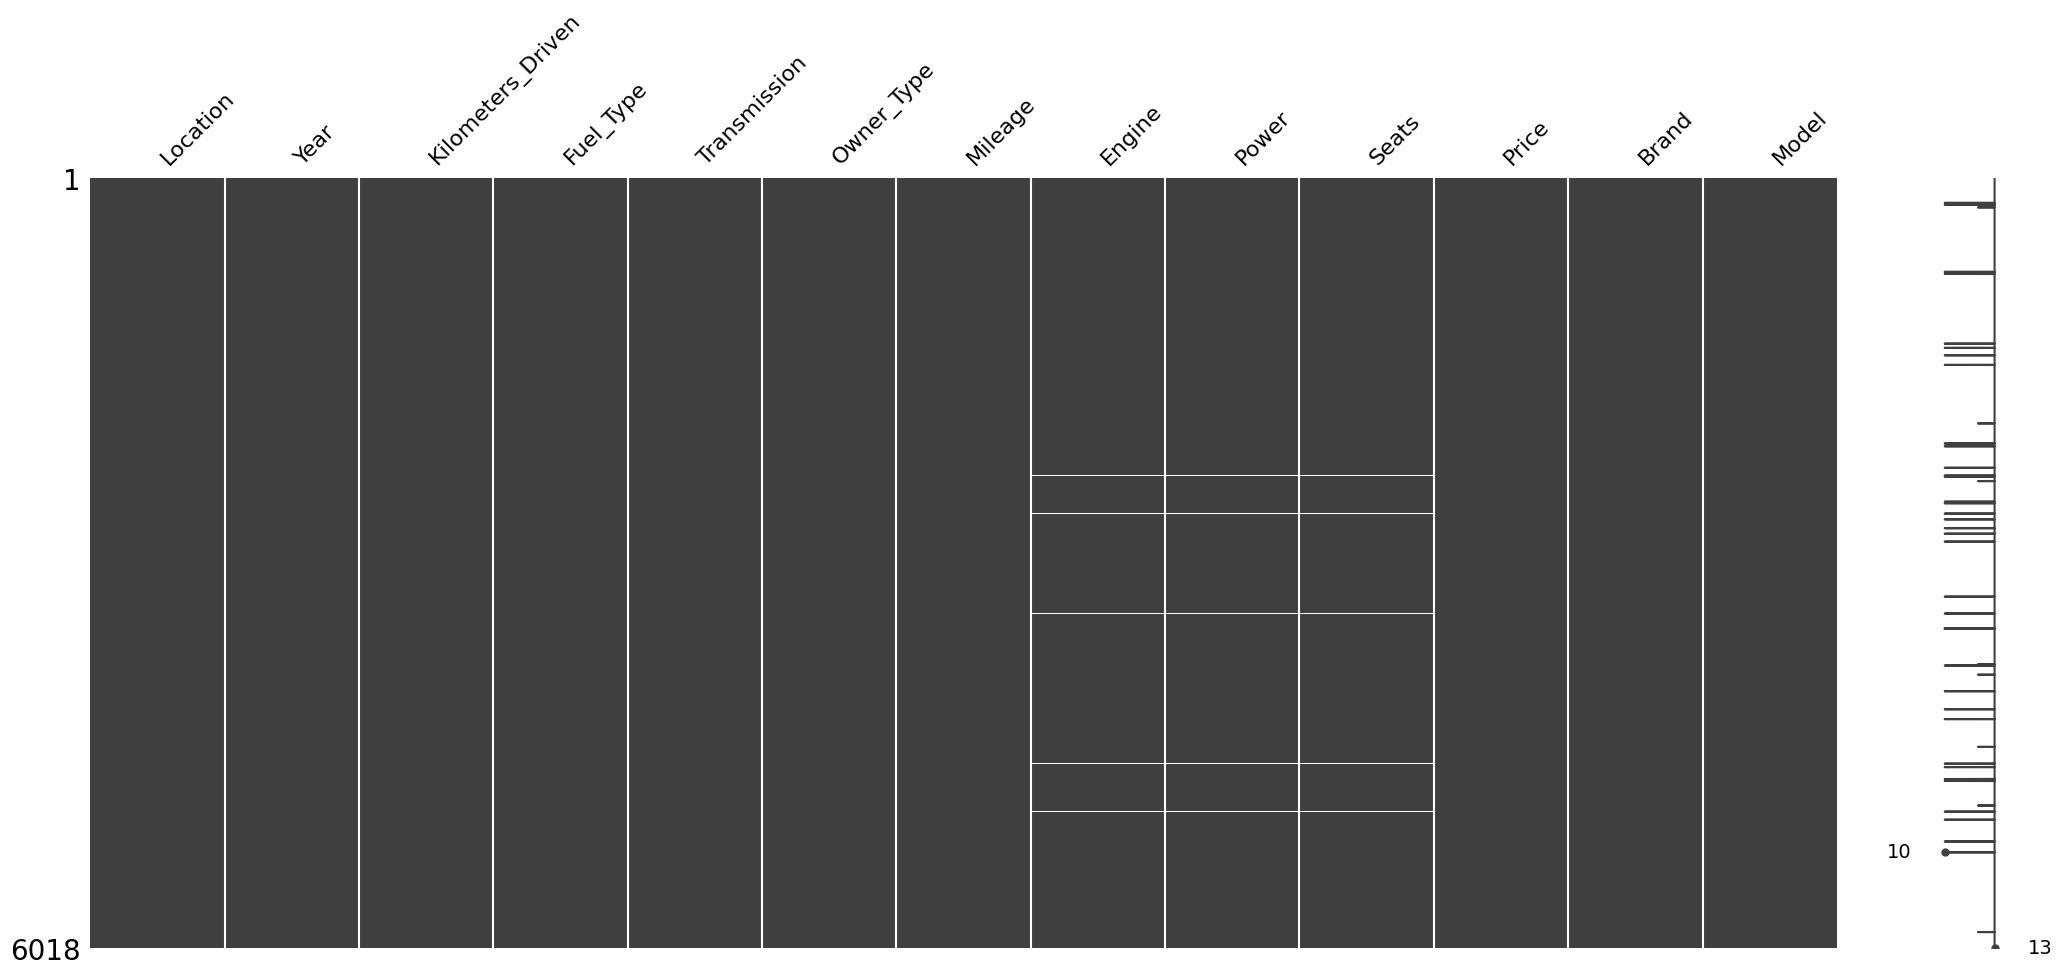

In [33]:
import missingno as msno

msno.matrix(df)

<Axes: >

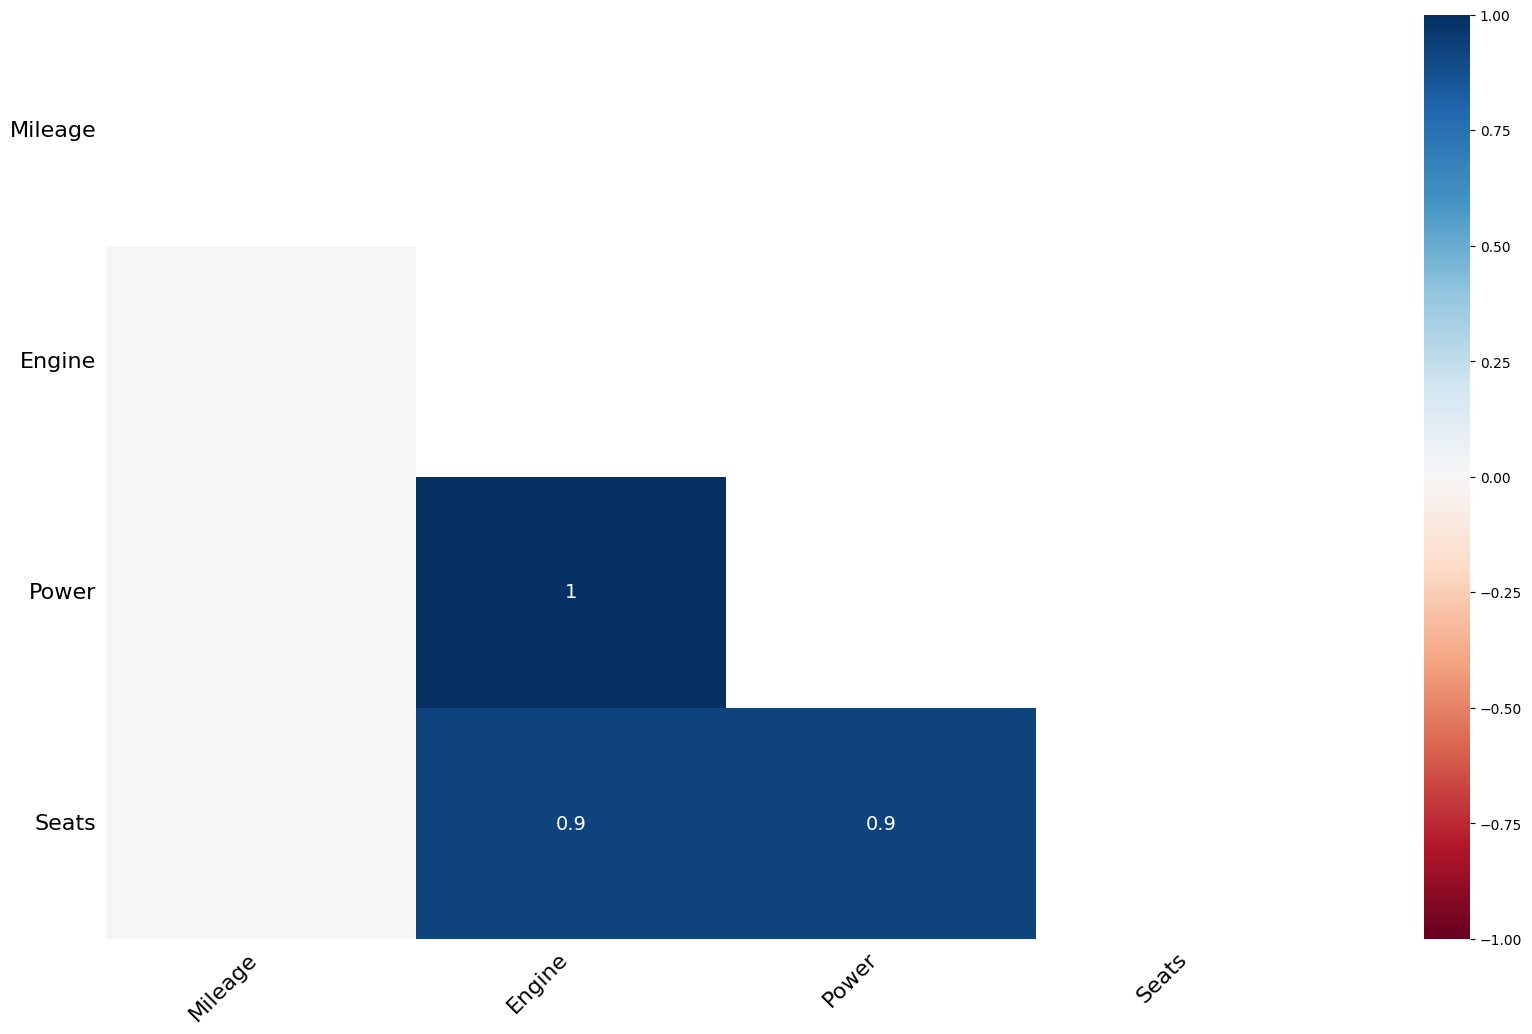

In [34]:
msno.heatmap(df)

In [35]:
df[df.Power.isna()]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
194,Ahmedabad,2007,60006,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN,2.950,Honda,City
208,Kolkata,2010,42001,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,2.110,Maruti,Swift
733,Chennai,2006,97800,Petrol,Manual,Third,16.1 kmpl,NaN,NaN,NaN,1.750,Maruti,Swift
749,Mumbai,2008,55001,Diesel,Automatic,Second,0.0 kmpl,NaN,NaN,NaN,26.500,Land Rover,Range Rover
1294,Delhi,2009,55005,Petrol,Manual,First,12.8 kmpl,NaN,NaN,NaN,3.200,Honda,City
1327,Hyderabad,2015,50295,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,5.800,Maruti,Swift
1385,Pune,2004,115000,Petrol,Manual,Second,0.0 kmpl,NaN,NaN,NaN,1.500,Honda,City
1460,Coimbatore,2008,69078,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN,40.880,Land Rover,Range Rover
2074,Pune,2011,24255,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,3.150,Maruti,Swift
2096,Coimbatore,2004,52146,Petrol,Manual,First,0.0 kmpl,NaN,NaN,NaN,1.930,Hyundai,Santro


* Mileage is missing in case of "Electric" cars.  
 Impute EV mileage as 0 and add a mileage_missing flag.

* Engine, Power and Seats are mostly missing together.  
 We will impute using median and add missing indicator.



In [36]:
df.Mileage.str.split(' ').str[1].unique()

array(['km/kg', 'kmpl', nan], dtype=object)

In [37]:
df.Fuel_Type.unique()

array(['CNG', 'Diesel', 'Petrol', 'LPG', 'Electric'], dtype=object)

In [38]:
# fuel densities (kg/L)
fuel_densities = {
    "CNG": 0.43,
    "Diesel": 0.832,
    "Petrol": 0.74,
    "LPG": 0.54,
    "Electric": 0
}

def convert_to_kmpl(row):
    if not pd.isna(row['Mileage']):
        fuel = row['Fuel_Type']
        mileage = float(row['Mileage'].split()[0])
        unit = row['Mileage'].split()[1]

        if mileage == 0:
            return np.nan

        if unit == 'km/kg':
            return mileage * fuel_densities[fuel]
        else:
            return mileage

# Apply conversion to DataFrame
df['Mileage'] = df.apply(convert_to_kmpl, axis=1)

In [39]:
df['Mileage'].describe()

,Mileage
count,"5,948.000"
mean,18.191
std,4.155
min,5.676
25%,15.100
50%,18.120
75%,21.030
max,28.400


In [40]:
df.Engine.str.split(' ').str[1].unique()

array(['CC', nan], dtype=object)

In [41]:
def get_engine(engine):
    if not pd.isna(engine):
        return float(engine.split(' ')[0])

df['Engine'] = df['Engine'].apply(get_engine)

In [42]:
df.Power.str.split(' ').str[1].unique()

array(['bhp', nan], dtype=object)

In [43]:
df.Power.sample(10)

,Power
2360,74 bhp
2727,88.76 bhp
2368,140 bhp
3294,79.4 bhp
3518,108.45 bhp
4726,174.33 bhp
4382,170 bhp
4240,138.1 bhp
5455,70 bhp
2181,46.3 bhp


In [44]:
def get_power(power):
    try:
        return float(power.split(' ')[0])
    except:
        return np.nan

df['Power'] = df['Power'].apply(get_power)

In [45]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,70
Engine,36
Power,143
Seats,42


In [46]:
# Remove zeros in Seats
df[df.Seats == 0].shape

(1, 13)

In [47]:
df = df[df.Seats != 0]

In [48]:
df.Seats.value_counts(normalize=True) * 100

,proportion
Seats,
5.000,83.900
7.000,11.280
8.000,2.243
4.000,1.657
6.000,0.519
2.000,0.268
10.000,0.084
9.000,0.050


In [49]:
df[df.Price > 100]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
4079,Hyderabad,2017,25000,Diesel,Automatic,First,13.330,"2,993.000",255.000,5.000,160.000,Land Rover,Range Rover
5781,Delhi,2011,6500,Petrol,Automatic,Third,6.400,"5,204.000",560.000,2.000,120.000,Lamborghini,Gallardo


In [50]:
# Remove outliers Where Price > 100
df = df[df.Price <= 100]

In [51]:
df.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,11.438,998.000,58.160,5.000,1.750,Maruti,Wagon
1,Pune,2015,41000,Diesel,Manual,First,19.670,"1,582.000",126.200,5.000,12.500,Hyundai,Creta
2,Chennai,2011,46000,Petrol,Manual,First,18.200,"1,199.000",88.700,5.000,4.500,Honda,Jazz
3,Chennai,2012,87000,Diesel,Manual,First,20.770,"1,248.000",88.760,7.000,6.000,Maruti,Ertiga
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.200,"1,968.000",140.800,5.000,17.740,Audi,A4


In [52]:
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,"6,015.000","6,015.000","5,945.000","5,979.000","5,873.000","5,973.000","6,015.000"
mean,"2,013.358","57,670.792",18.195,"1,619.955",113.128,5.280,9.425
std,3.270,"37,870.190",4.152,598.896,53.507,0.805,10.905
min,"1,998.000",171.000,5.676,72.000,34.200,2.000,0.440
25%,"2,011.000","34,000.000",15.150,"1,198.000",75.000,5.000,3.500
50%,"2,014.000","53,000.000",18.120,"1,493.000",97.700,5.000,5.630
75%,"2,016.000","73,000.000",21.030,"1,984.000",138.100,5.000,9.950
max,"2,019.000","775,000.000",28.400,"5,998.000",552.000,10.000,100.000


In [53]:
df.describe(include='O')

,Location,Fuel_Type,Transmission,Owner_Type,Brand,Model
count,6015,6015,6015,6015,6015,6015
unique,11,5,2,4,30,213
top,Mumbai,Diesel,Manual,First,Maruti,Swift
freq,790,3203,4299,4926,1211,353


In [54]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    fig = px.histogram(df, x=col, marginal='box', title=f'Distribution of {col}', nbins=30)
    fig.show()

In [55]:
df.shape

(6015, 13)

In [56]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,70
Engine,36
Power,142
Seats,42


<Axes: >

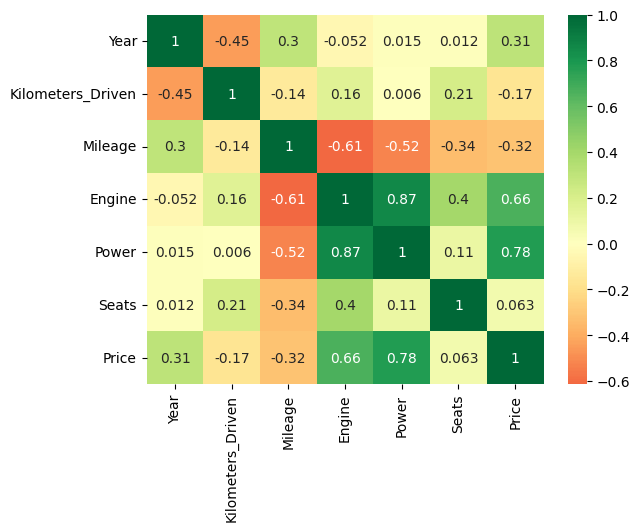

In [57]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', center=0)

In [58]:
asc_num_features = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)
asc_num_features.drop('Price', inplace=True)
asc_num_features

,Price
Power,0.776
Engine,0.661
Year,0.311
Seats,0.063
Kilometers_Driven,-0.168
Mileage,-0.315


In [59]:
px.bar(asc_num_features, width=600, category_orders={'index':asc_num_features.index}, orientation='h')

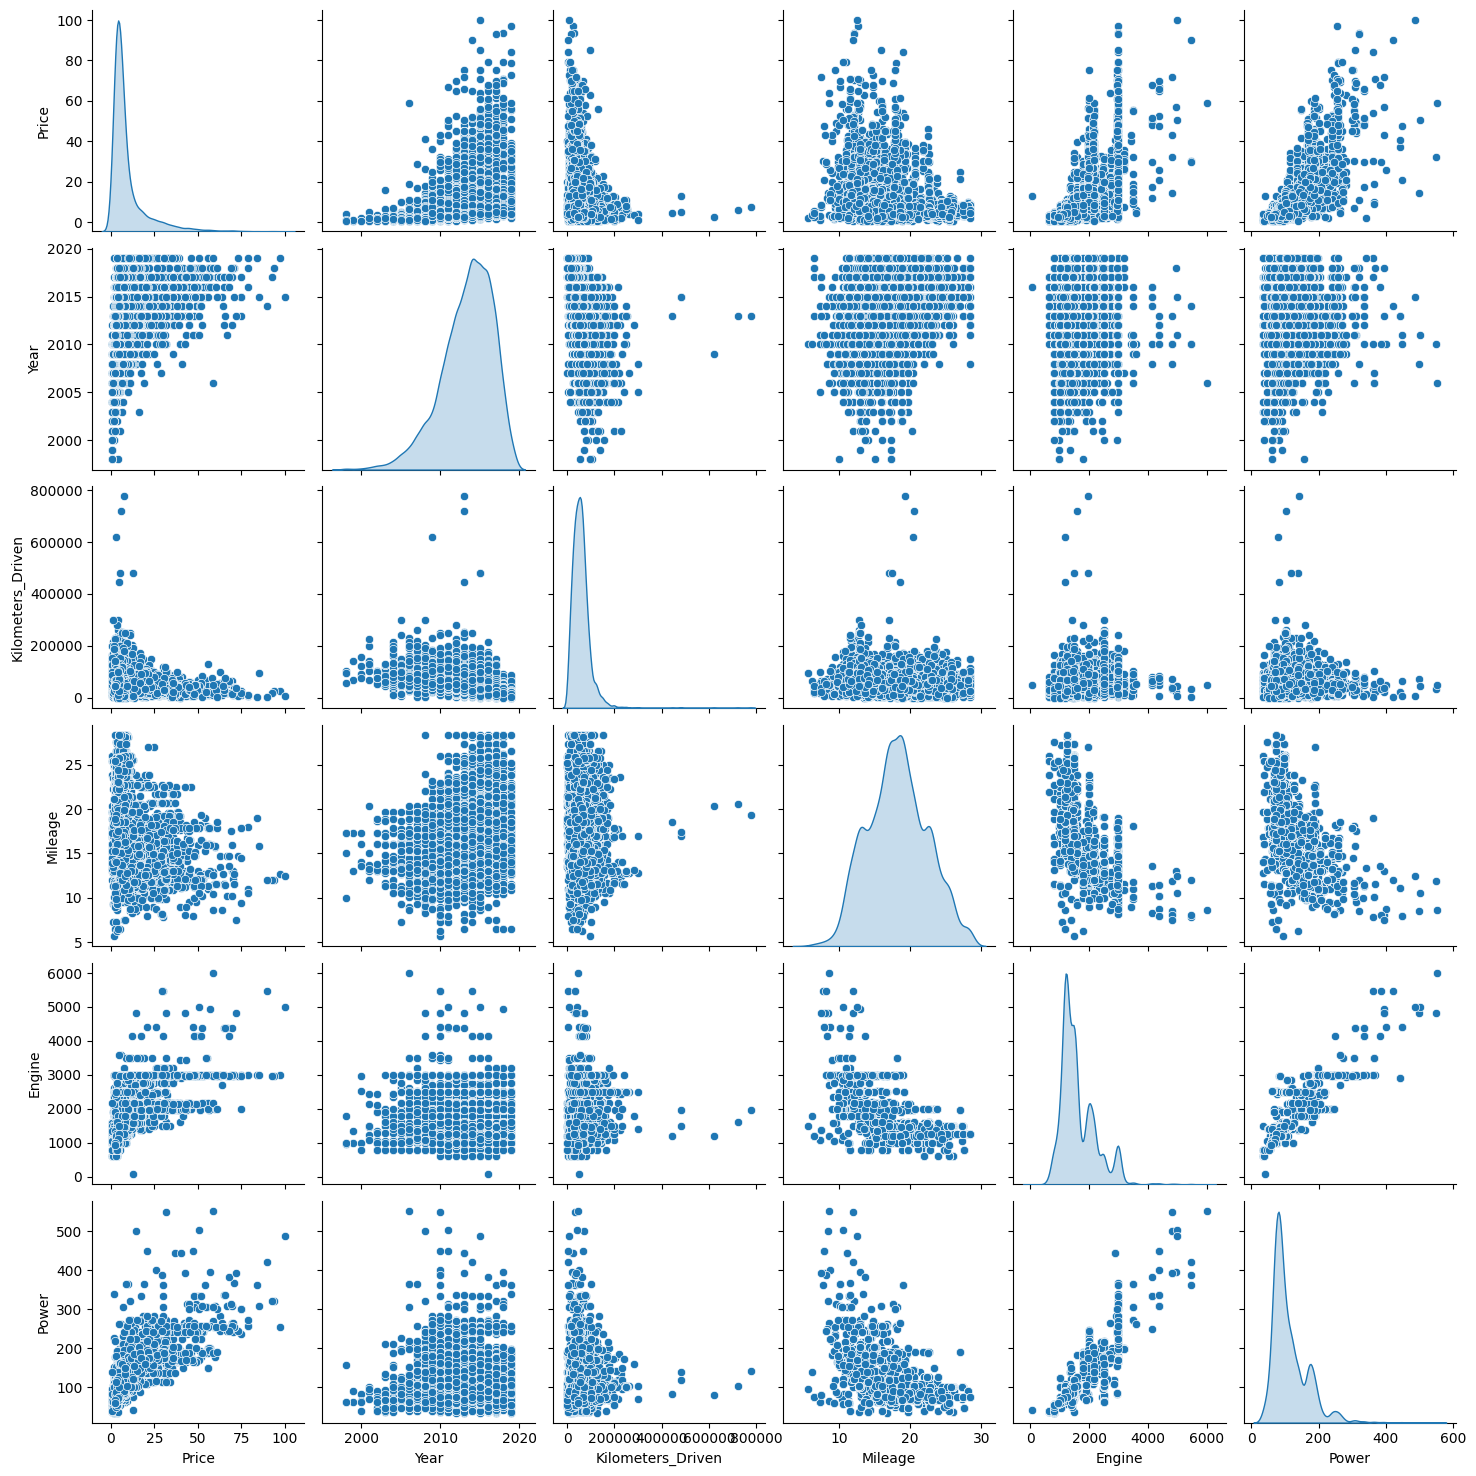

In [60]:
sns.pairplot(df[['Price', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power']], diag_kind='kde')

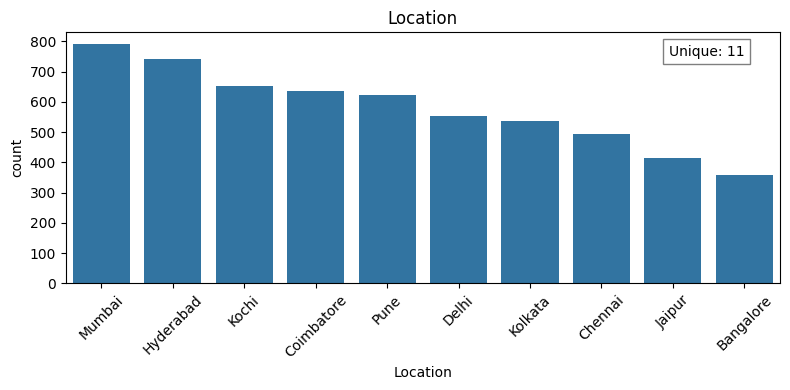

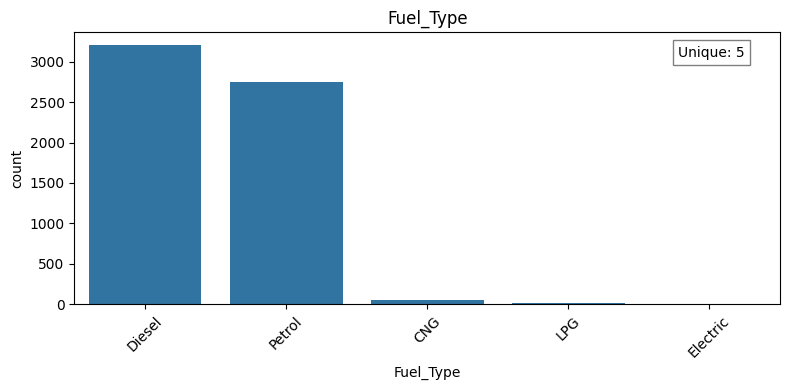

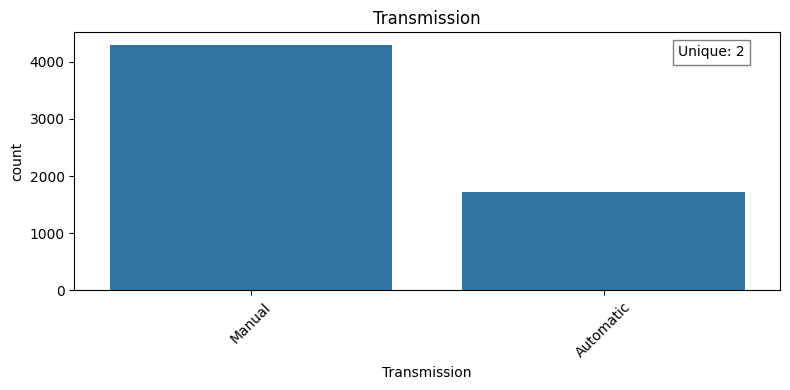

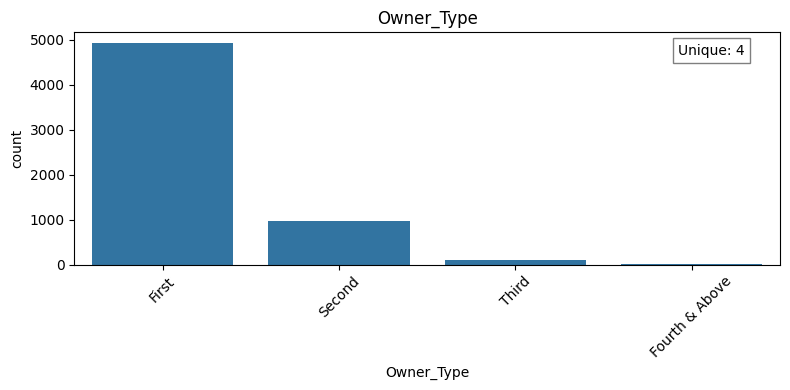

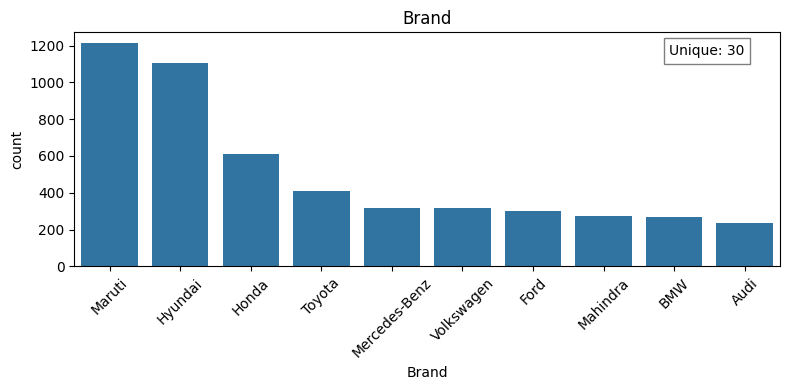

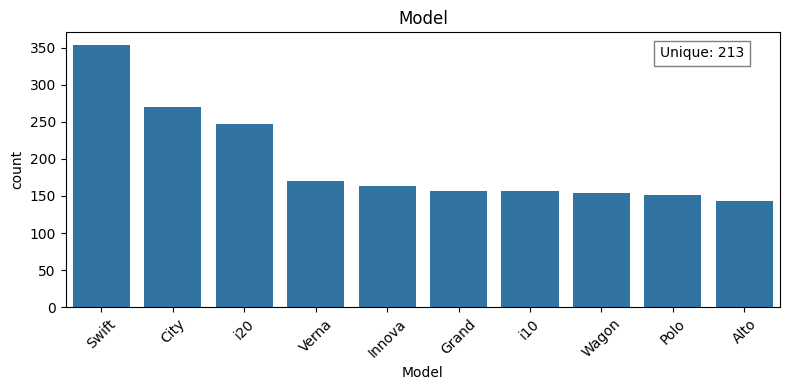

In [61]:
def univariable_categorical(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # Plot Bar plots for categorical features (top 10 categories)
    for col in cat_cols:
        # Get top 10 categories
        top_10 = df[col].value_counts().nlargest(10)
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, order=top_10.index)
        plt.title(f'{col}')
        plt.xticks(rotation=45)
        # Annotate No. of unique values with box
        n_unique = df[col].nunique()
        plt.text(0.95, 0.95, f'Unique: {n_unique}', horizontalalignment='right', verticalalignment='top',
                 transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
        plt.tight_layout()
        plt.show()

univariable_categorical(df)

* `Brand` and `Model` are nominal categorical features with high cardinality.  
   binary encoding
* `Location` is a nominal categorical feature with medium cardinality.
   binary encoding
* `Transmission` is a binary categorical feature.
    one-hot encoding (take care of drop first)
* `Fuel_Type` is a nominal categorical feature with some rare categories.
    one-hot encoding (take care of rare categories)
* `Owner_Type` is an ordinal categorical feature.
   ordinal encoder

# PREPROCCESSING AND MODELING

In [62]:
df.isna().sum()

,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,70
Engine,36
Power,142
Seats,42


<Axes: >

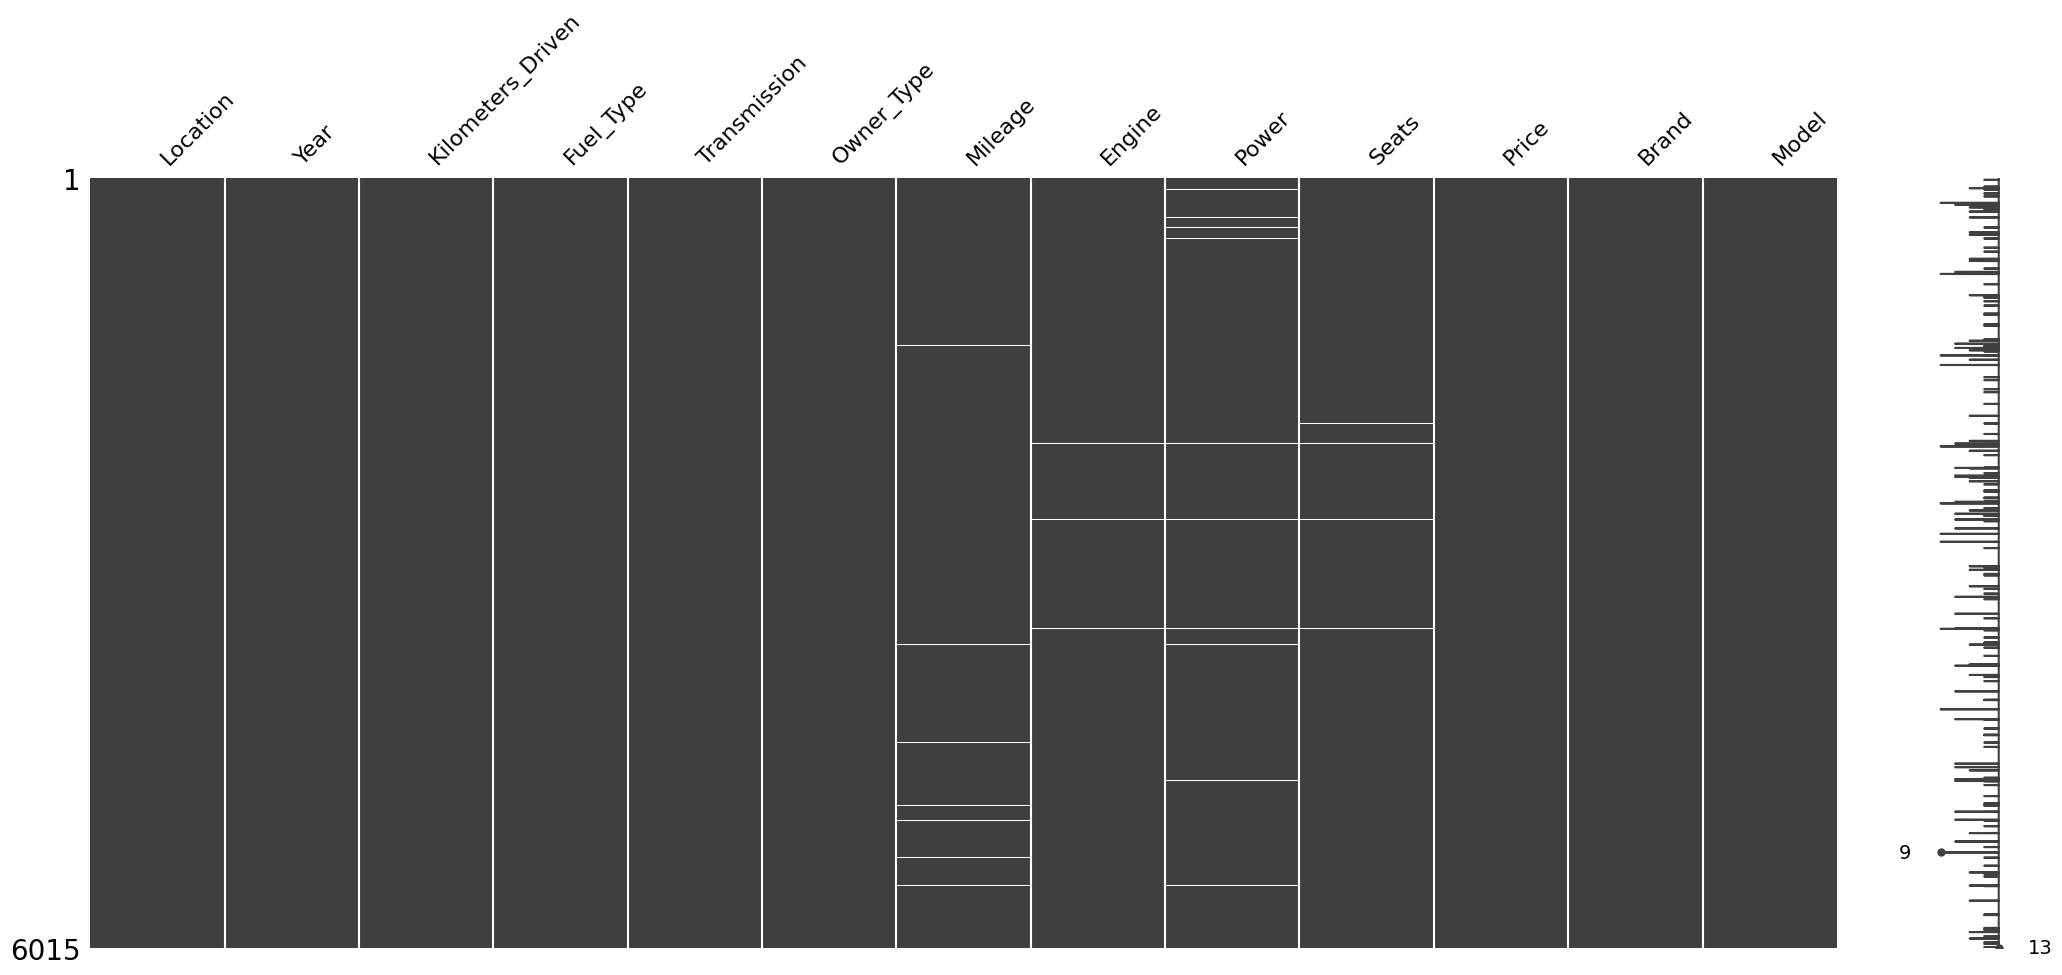

In [63]:
import missingno as msno

msno.matrix(df)

In [64]:
# Data Splitting

X = df.drop(columns=['Price']).copy()
y = df['Price'].copy()

In [65]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
X_train.shape

(4812, 12)

In [67]:
!pip install category_encoders
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from category_encoders import BinaryEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [68]:
# Very Simple Preprocessing & Base Model
num_cols = ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
nom_cat_cols = ['Location', 'Fuel_Type', 'Transmission', 'Brand', 'Model']
ord_cat_cols = ['Owner_Type']

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
bin_enc = BinaryEncoder()
ord_enc = OrdinalEncoder(categories=[['Fourth & Above', 'Third', 'Second', 'First']],
                         handle_unknown="use_encoded_value", unknown_value=-1)


num_pipeline = Pipeline(steps=[ ('imputer', imputer),
                                ('scaler', scaler)
                              ])
transformer = ColumnTransformer(transformers=[
                                                ('num', num_pipeline, num_cols),
                                                ('bin_enc', bin_enc, nom_cat_cols),
                                                ('ord_enc', ord_enc, ord_cat_cols)
                                            ], remainder='passthrough'
                                )

# Linear Regression
lr = LinearRegression()
pipe = Pipeline(steps=[ ('preprocessor', transformer),
                        ('model', lr)
                      ])

scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
print("Cross-validated R²: %.2f (± %.2f)" % (scores.mean(), scores.std() * 2))

Cross-validated R²: 0.73 (± 0.04)


In [69]:
# Custom Imputer for Mileage based on Fuel_Type

from sklearn.base import BaseEstimator, TransformerMixin

class MileageFuelImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.medians = None
        self.default_median = None

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input X must be a pandas DataFrame")
        if not all(col in X.columns for col in ['Mileage', 'Fuel_Type']):
            raise ValueError("X must contain 'Mileage' and 'Fuel_Type' columns")
        self.medians = X.groupby('Fuel_Type')['Mileage'].median()
        self.medians['Electric'] = 0  # Configurable default
        self.default_median = X['Mileage'].median()  # Fallback for unseen Fuel_Type
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input X must be a pandas DataFrame")
        if not all(col in X.columns for col in ['Mileage', 'Fuel_Type']):
            raise ValueError("X must contain 'Mileage' and 'Fuel_Type' columns")
        X = X.copy()  # Avoid modifying input
        X['Mileage'] = X.apply(
            lambda row: self.medians.get(row['Fuel_Type'], self.default_median)
            if pd.isna(row['Mileage']) else row['Mileage'], axis=1)
        return X[['Mileage']].values  # Return only Mileage

    def get_feature_names_out(self, input_features=None):
        return ['Mileage']  # Explicitly define output feature name


In [70]:
# Improved Preprocessing & Base Model

num_cols_norm = ['Engine', 'Power', 'Seats']
num_cols_log = ['Kilometers_Driven']
nom_cat_cols = ['Location', 'Fuel_Type', 'Transmission', 'Brand', 'Model']
ord_cat_cols = ['Owner_Type']

imputer = SimpleImputer(strategy="median")
mileage_imputer = MileageFuelImputer()
scaler  = RobustScaler()
bin_enc = BinaryEncoder()
ord_enc = OrdinalEncoder(categories=[['Fourth & Above', 'Third', 'Second', 'First']],
                         handle_unknown="use_encoded_value", unknown_value=-1)

log_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one" )

num_pipeline = Pipeline(steps=[ ('imputer', imputer),
                                ('scaler', scaler)
                              ])

mileage_pipeline = Pipeline(steps=[ ('imputer', mileage_imputer),
                                    ('scaler', scaler)
                                  ])

log_pipeline = Pipeline(steps=[ ('imputer', imputer),
                              ('log_transform', log_transformer),
                              ('scaler', scaler)
                            ])
transformer = ColumnTransformer(transformers=[
                                                ('num', num_pipeline, num_cols_norm),
                                                ('mileage', mileage_pipeline, ['Mileage', 'Fuel_Type']),
                                                ('log_transform', log_pipeline, num_cols_log),
                                                ('bin_enc', bin_enc, nom_cat_cols),
                                                ('ord_enc', ord_enc, ord_cat_cols)
                                            ], remainder='passthrough'
                                )


# Linear Regression
lr = LinearRegression()
pipe = Pipeline(steps=[ ('preprocessor', transformer),
                        ('model', lr)
                      ])

scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
print("Cross-validated R²: %.2f (± %.2f)" % (scores.mean(), scores.std() * 2))

Cross-validated R²: 0.73 (± 0.04)


In [71]:
# Linear Regression
lr = LinearRegression()
pipe = Pipeline(steps=[ ('preprocessor', transformer),
                        ('model', lr)
                      ])

# Applying Log Transformation to Price
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

scores = cross_val_score(pipe, X_train, y_train_log, cv=5, scoring='r2')
print("Cross-validated R²: %.2f (± %.2f)" % (scores.mean(), scores.std() * 2))

Cross-validated R²: 0.88 (± 0.01)


In [72]:
import plotly.express as px

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)
lr.fit(X_train_transformed, y_train_log)

feature_importance = dict(zip(transformer.get_feature_names_out(), lr.coef_))
feature_importance = pd.Series(feature_importance).sort_values()
px.bar(feature_importance, width=800, height=900, orientation='h', title='Feature Importance')

In [73]:
# Keep the same variable names in memory
X_train_unpreprocessed = X_train
y_train_unpreprocessed = y_train
X_test_unpreprocessed = X_test
y_test_unpreprocessed = y_test

X_train_prep = X_train_transformed
y_train_log_prep = y_train_log
X_test_prep = X_test_transformed
y_test_log_prep = y_test_log

# MODEL

In [74]:
import pickle
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer, PolynomialFeatures
from category_encoders import BinaryEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor

In [75]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_prep, y_train_log)   # Learn Weights from training data Using OLS (Normal Equation)

lr_scores = cross_val_score(lr, X_train_prep, y_train_log, cv=5, scoring='r2')
print(f"Linear Regression: {np.mean(lr_scores)}")

Linear Regression: 0.8822780005707239


In [76]:
scores_dict = {'Linear Regression': round(np.mean(lr_scores), 2)}
scores_dict

{'Linear Regression': np.float64(0.88)}

In [77]:
# Polynomial Regression

#  Preprocessing & Base Model

num_cols_norm = ['Engine', 'Power', 'Mileage', 'Seats']
num_cols_log = ['Kilometers_Driven']
nom_cat_cols = ['Location', 'Fuel_Type', 'Transmission', 'Brand', 'Model']
ord_cat_cols = ['Owner_Type']

imputer = SimpleImputer(strategy="median")
scaler  = RobustScaler()
bin_enc = BinaryEncoder()
ord_enc = OrdinalEncoder(categories=[['Fourth & Above', 'Third', 'Second', 'First']],
                         handle_unknown="use_encoded_value", unknown_value=-1)

poly = PolynomialFeatures(degree=2, include_bias=False)

log_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one" )

num_pipeline = Pipeline(steps=[ ('imputer', imputer),
                                ('poly', poly),
                                ('scaler', scaler)
                              ])
log_pipeline = Pipeline(steps=[ ('imputer', imputer),
                              ('log_transform', log_transformer),
                              ('poly', poly),
                              ('scaler', scaler)
                            ])
transformer = ColumnTransformer(transformers=[
                                                ('num', num_pipeline, num_cols_norm),
                                                ('log_transform', log_pipeline, num_cols_log),
                                                ('bin_enc', bin_enc, nom_cat_cols),
                                                ('ord_enc', ord_enc, ord_cat_cols)
                                            ], remainder='passthrough'
                                )


# Linear Regression
lr = LinearRegression()
pipe = Pipeline(steps=[ ('preprocessor', transformer),
                        ('model', lr)
                      ])


poly2_scores = cross_val_score(pipe, X_train, y_train_log, cv=5, scoring='r2')
print("Cross-validated R²: %.2f (± %.2f)" % (poly2_scores.mean(), poly2_scores.std() * 2))

Cross-validated R²: 0.89 (± 0.02)


In [78]:
scores_dict.update({'Polynomial Regression (2)': round(np.mean(poly2_scores), 2)})
scores_dict

{'Linear Regression': np.float64(0.88),
 'Polynomial Regression (2)': np.float64(0.89)}

In [79]:
# Grid Search with Ridge Regression (tuning alpha and polynomial degree)
ridge = Ridge()
pipe_ridge = Pipeline(steps=[ ('preprocessor', transformer),
                              ('model', ridge)
                            ])
param_grid = {
    'preprocessor__num__poly__degree': [1, 2, 3, 4],
    'model__alpha': [0.01, 0.1, 1.0, 10.0]
}
ridge_search = GridSearchCV(pipe_ridge, param_grid, cv=5, scoring='r2')
ridge_search.fit(X_train, y_train_log)
print("Best parameters:", ridge_search.best_params_)
print("Best cross-validated R²: %.2f" % ridge_search.best_score_)

Best parameters: {'model__alpha': 1.0, 'preprocessor__num__poly__degree': 3}
Best cross-validated R²: 0.90


In [80]:
scores_dict.update({'Ridge Regression (3)': round(ridge_search.best_score_ , 2)})
scores_dict

{'Linear Regression': np.float64(0.88),
 'Polynomial Regression (2)': np.float64(0.89),
 'Ridge Regression (3)': np.float64(0.9)}

In [81]:
# Grid Search with Decision Tree
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
pipe_dt = Pipeline(steps=[ ('preprocessor', transformer),
                           ('model', dt)
                         ])
param_grid_dt = {
    'preprocessor__num__poly__degree': [1],
    'model__max_depth': [5, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='r2')
grid_search_dt.fit(X_train, y_train_log)
print("Best parameters:", grid_search_dt.best_params_)
print("Best cross-validated R²: %.2f" % grid_search_dt.best_score_)

Best parameters: {'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'preprocessor__num__poly__degree': 1}
Best cross-validated R²: 0.90


In [82]:
scores_dict.update({'Decision Tree Regressor': round(grid_search_dt.best_score_, 2)})
scores_dict

{'Linear Regression': np.float64(0.88),
 'Polynomial Regression (2)': np.float64(0.89),
 'Ridge Regression (3)': np.float64(0.9),
 'Decision Tree Regressor': np.float64(0.9)}

In [83]:
# Grid Search with RandomForest Regressor
# Random Forest
rf = RandomForestRegressor(random_state=42)
pipe_rf = Pipeline(steps=[ ('preprocessor', transformer),
                           ('model', rf)
                         ])
param_grid_rf = {
    'preprocessor__num__poly__degree': [1],
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}
grid_search_rf = GridSearchCV(pipe_rf, param_grid_dt, cv=5, scoring='r2')
grid_search_rf.fit(X_train, y_train_log)
print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validated R²: %.2f" % grid_search_rf.best_score_)

Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'preprocessor__num__poly__degree': 1}
Best cross-validated R²: 0.94


In [84]:
scores_dict.update({'RandomForest Regressor': round(grid_search_rf.best_score_, 2)})
scores_dict

{'Linear Regression': np.float64(0.88),
 'Polynomial Regression (2)': np.float64(0.89),
 'Ridge Regression (3)': np.float64(0.9),
 'Decision Tree Regressor': np.float64(0.9),
 'RandomForest Regressor': np.float64(0.94)}

In [85]:
# XGBoost
# XGBRegressor model
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Pipeline with preprocessing + model
pipe_xgb = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', xgb)
])

# Hyperparameter grid
param_grid_xgb = {
    'preprocessor__num__poly__degree': [1],
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__gamma': [0, 0.1, 0.2]
}

# Grid search with 5-fold CV
grid_search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train_log)

print("Best parameters:", grid_search_xgb.best_params_)
print("Best cross-validated R²: %.2f" % grid_search_xgb.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'preprocessor__num__poly__degree': 1, 'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 1.0}
Best cross-validated R²: 0.95


In [86]:
# Best Model
scores_dict.update({'XGB Regressor': round(grid_search_xgb.best_score_, 2)})
scores_dict

{'Linear Regression': np.float64(0.88),
 'Polynomial Regression (2)': np.float64(0.89),
 'Ridge Regression (3)': np.float64(0.9),
 'Decision Tree Regressor': np.float64(0.9),
 'RandomForest Regressor': np.float64(0.94),
 'XGB Regressor': np.float64(0.95)}

In [87]:
scores_df = pd.DataFrame(list(scores_dict.items()), columns=['Model', 'CV Avg R² Score'])
scores_df = scores_df.sort_values(by='CV Avg R² Score', ascending=False).reset_index(drop=True)
scores_df

,Model,CV Avg R² Score
0,XGB Regressor,0.950
1,RandomForest Regressor,0.940
2,Decision Tree Regressor,0.900
3,Ridge Regression (3),0.900
4,Polynomial Regression (2),0.890
5,Linear Regression,0.880


In [88]:
print ('Best Model:',  scores_df.nlargest(1, 'CV Avg R² Score')['Model'][0])

Best Model: XGB Regressor


In [89]:
# Final Evaluation
best_model = grid_search_xgb.best_estimator_
y_pred_log = best_model.predict(X_test)

print('Testing R2 Score: ', round(best_model.score(X_test, y_test_log), 2))

Testing R2 Score:  0.96
